# Anatomie du Hovmöller $\bar u'(z,t)$ — décomposition humide / sec, gradients, rôle de la subsidence
## Méso-NH RCE `large300`

On reprend le setup commun et le Hovmöller de la figure de départ tels quels, puis on les décompose entièrement : gradients $\partial_z$ vs $\partial_t$, séparation spatiale humide/sec du signal ($\bar u = f_h\bar u_h + f_s\bar u_s$, exacte), tendances et cisaillement par zone (`dtuc`/`dtus`, `dzuc`/`dzus`), et confrontation à $\bar w$ pour trancher entre onde propagative et subsidence à grande échelle qui advecte simplement l'anomalie vers le bas.

## §0. Setup et champs de base (recopié à l'identique)

In [10]:
# ============================================================
#  SETUP COMMUN — pipeline large300 (RCEMIP Meso-NH)
# ============================================================
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm
import xarray as xr
import gc, os
from scipy.signal import detrend, hilbert
from scipy.ndimage import uniform_filter1d

plt.rcParams.update({'figure.dpi':120,'font.size':11,'axes.grid':True,
                     'grid.alpha':0.25,'image.cmap':'RdBu_r'})
Rd,Rv=287.05,461.5; EPSILON=Rd/Rv; g=9.81; KARMAN=0.4
Z_TOP_KM=15.0
DIR_3D,DIR_2D,DIR_1D='3D','2D','1D'
def path3d(v): return os.path.join(DIR_3D,f'MESONH_RCE_large300_3D_{v}.nc')
def path2d(v): return os.path.join(DIR_2D,f'MESONH_RCE_large300_2D_{v}.nc')
def path1d(v): return os.path.join(DIR_1D,f'MESONH_RCE_large300_1D_{v}.nc')
BLOC=2

_ds=xr.open_dataset(path3d('ua')); _da=_ds['ua']
dim_t,dim_z,dim_y,dim_x=_da.dims[:4]
n_t,n_z=_da.sizes[dim_t],_da.sizes[dim_z]; n_y,n_x=_da.sizes[dim_y],_da.sizes[dim_x]
_xv=_da[dim_x].values; dx=float(np.mean(np.diff(_xv))) if _xv.size>1 else 1000.0
if abs(dx)<=1.5: dx=1000.0
_ds.close(); del _ds,_da; gc.collect()
_ds1=xr.open_dataset(path1d('ua_avg')); alt=_ds1.altitude.values.astype(float).copy(); _ds1.close()
x=np.arange(n_x,dtype=float)*dx; zkm=alt/1000.0
mask_show=alt<=Z_TOP_KM*1000; m28=(alt>=2000)&(alt<=8000)

# fenetre stationnaire = toute la fenetre (RCE quasi-stationnaire, cf. runs precedents)
t_stat=0; idx_stat=slice(t_stat,None); n_stat=n_t-t_stat
dt_phys=6*3600.0                      # RCEMIP : snapshots 3D 6-horaires

# masques humide/sec (PRW)
ds_prw=xr.open_dataset(path2d('prw')); prw_all=ds_prw['prw'].load(); ds_prw.close()
prw_mean=prw_all.isel({dim_t:idx_stat}).mean(dim=dim_t)
PRW_SEUIL=float(np.median(prw_all.values.ravel()))
mh=(prw_mean.values>PRW_SEUIL); ms=~mh; del prw_all; gc.collect()

print(f'{n_t} t x {n_z} z x {n_y} y x {n_x} x | dx={dx:.0f}m | dt={dt_phys/3600:.0f}h')
print(f'altitude {alt[0]:.0f}-{alt[-1]:.0f}m | z[1]={alt[1]:.0f}m | fenetre {n_stat} pas = {n_stat*dt_phys/86400:.0f} j')
print(f'humide {mh.mean()*100:.0f}% / sec {ms.mean()*100:.0f}% (seuil PRW={PRW_SEUIL:.1f})')


100 t x 74 z x 128 y x 2000 x | dx=1000m | dt=6h
altitude 0-32500m | z[1]=37m | fenetre 100 pas = 25 j
humide 43% / sec 57% (seuil PRW=30.4)


In [11]:
# ============================================================
#  CHAMPS DE BASE : rho0(z), profils ET champs (z,t)
#   - profils moyens : flux_tot, ubar, dudz, uw       (1D, pour §1-§5-§6)
#   - champs (z,t)   : flux_zt, ubar_zt, wbar_zt, ...  (2D, pour le contexte)
# ============================================================
# rho0(z)
rho0_sum=np.zeros(n_z); n_rho=0
ds_ta=xr.open_dataset(path3d('ta')); ds_pa=xr.open_dataset(path3d('pa')); ds_hus=xr.open_dataset(path3d('hus'))
for t0 in range(t_stat,n_t,BLOC):
    t1=min(t0+BLOC,n_t); sl={dim_t:slice(t0,t1)}
    T=ds_ta['ta'].isel(sl).values; p=ds_pa['pa'].isel(sl).values; qv=ds_hus['hus'].isel(sl).values
    Tv=T*(1+qv/EPSILON)/(1+qv); rho=p/(Rd*Tv)
    rho0_sum+=rho.mean(axis=(0,2,3))*(t1-t0); n_rho+=(t1-t0)
    del T,p,qv,Tv,rho; gc.collect()
ds_ta.close(); ds_pa.close(); ds_hus.close(); rho0=rho0_sum/n_rho

# champs (z,t) : flux, ubar, wbar   (niveau par niveau)
flux_zt=np.zeros((n_z,n_stat)); ubar_zt=np.zeros((n_z,n_stat)); wbar_zt=np.zeros((n_z,n_stat))
ds_u=xr.open_dataset(path3d('ua')); ds_w=xr.open_dataset(path3d('wa'))
for iz in range(n_z):
    u=ds_u['ua'].isel({dim_t:idx_stat,dim_z:iz}).values
    w=ds_w['wa'].isel({dim_t:idx_stat,dim_z:iz}).values
    ub=u.mean(axis=(1,2)); wb=w.mean(axis=(1,2))
    up=u-ub[:,None,None]; wp=w-wb[:,None,None]
    flux_zt[iz]=rho0[iz]*(up*wp).mean(axis=(1,2)); ubar_zt[iz]=ub; wbar_zt[iz]=wb
    del u,w,up,wp; gc.collect()
ds_u.close(); ds_w.close(); gc.collect()

# profils moyens (moyenne temporelle des champs zt)
flux_tot=flux_zt.mean(1); ubar=ubar_zt.mean(1); wbar=wbar_zt.mean(1)
uw=flux_tot/rho0; dudz=np.gradient(ubar,alt); d2udz2=np.gradient(dudz,alt)
# derivees des champs zt (pour le contexte dynamique)
dudz_zt=np.gradient(ubar_zt,alt,axis=0); d2udz2_zt=np.gradient(dudz_zt,alt,axis=0)
uw_zt=flux_zt/rho0[:,None]
print(f'rho0 surface={rho0[0]:.3f} | ~10km={rho0[np.argmin(np.abs(alt-10000))]:.3f} kg/m3')
print('profils (flux_tot,ubar,dudz,uw) et champs (flux_zt,ubar_zt,...) prets.')


rho0 surface=1.183 | ~10km=0.410 kg/m3
profils (flux_tot,ubar,dudz,uw) et champs (flux_zt,ubar_zt,...) prets.


## §1. Hovmöller de référence $\bar u'(z,t)$ (recopié)

Anomalie temporelle du vent moyen (moyenne spatiale $x,y$), lissée sur 3 niveaux verticaux. C'est ce diagramme (bandes rouges/bleues qui migrent vers le bas) qu'on va décomposer et expliquer.

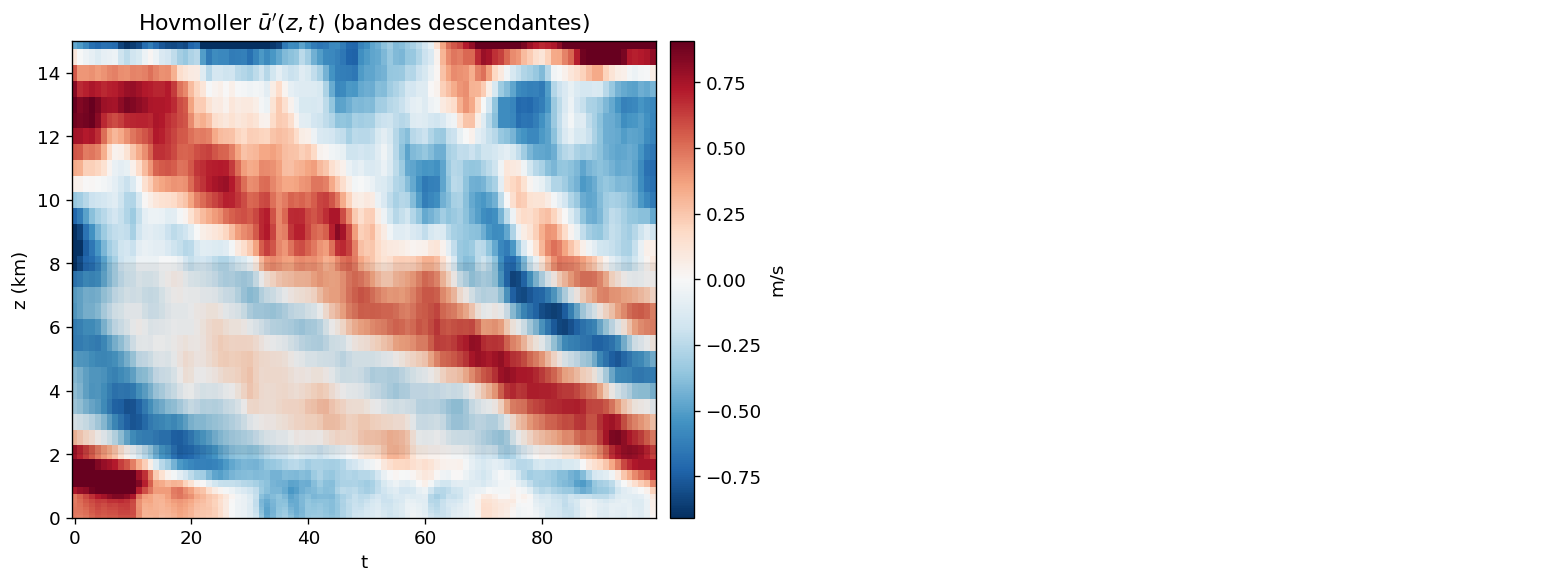

In [12]:
# ============================================================
#  CONTEXTE — Descente de phase (Hovmoller + c_z en cm/s)
# ============================================================
uprime=ubar_zt-ubar_zt.mean(axis=1,keepdims=True)
ups=uniform_filter1d(uprime,size=3,axis=0,mode='nearest')
tt=np.arange(n_stat)
fig,axes=plt.subplots(1,2,figsize=(13,5))
ax=axes[0]; ax.grid(False)
v=np.percentile(np.abs(ups[mask_show]),98)+1e-9
im=ax.pcolormesh(tt+t_stat,zkm[mask_show],ups[mask_show],cmap='RdBu_r',
                 norm=TwoSlopeNorm(0,-v,v),shading='auto')
ax.axhspan(2,8,color='k',alpha=.06); ax.set_ylim(0,Z_TOP_KM)
ax.set_xlabel('t'); ax.set_ylabel('z (km)')
ax.set_title(r"Hovmoller $\bar u'(z,t)$ (bandes descendantes)")
fig.colorbar(im,ax=ax,pad=.02,label='m/s')
axes[1].axis('off')
plt.tight_layout(); plt.show()


## §3. Gradients locaux $\partial_z\bar u'$ et $\partial_t\bar u'$

/tmp/ipykernel_6259/1426768322.py:12: MatplotlibDeprecationWarning: Auto-removal of grids by pcolor() and pcolormesh() is deprecated since 3.5 and will be removed two minor releases later; please call grid(False) first.
  im=ax.pcolormesh(tt+t_stat, zkm[mask_show], fld[mask_show], cmap='RdBu_r',


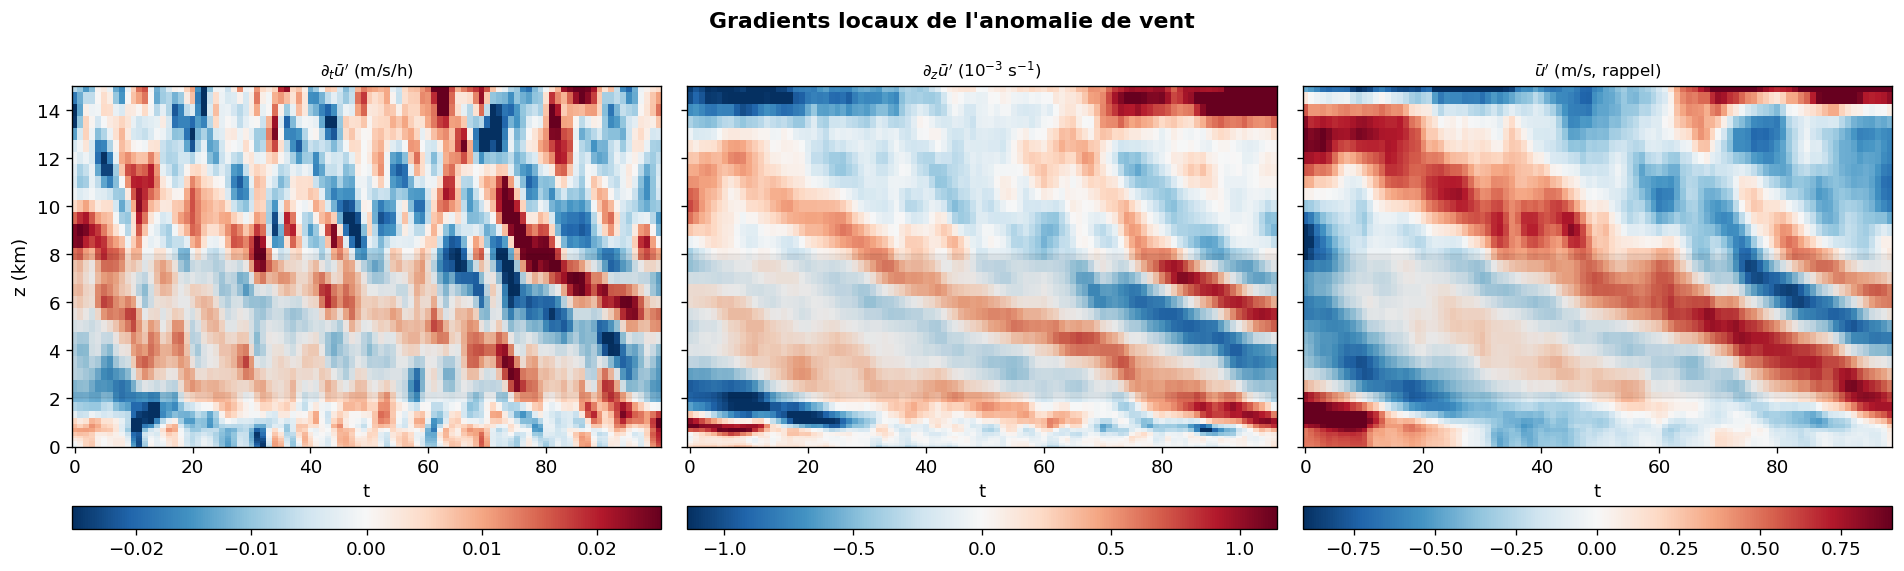

In [21]:
# ============================================================
#  GRADIENTS LOCAUX dz et dt DE u'(z,t)
# ============================================================
dudt_prime = np.gradient(ups, dt_phys, axis=1)   # m/s par seconde
dudz_prime = np.gradient(ups, alt, axis=0)       # m/s par metre

fig,axes=plt.subplots(1,3,figsize=(16,5),sharey=True)
for ax,(fld,lab) in zip(axes,[(dudt_prime*3600,r"$\partial_t\bar u'$ (m/s/h)"),
                               (dudz_prime*1e3,r"$\partial_z\bar u'$ ($10^{-3}$ s$^{-1}$)"),
                               (ups, r"$\bar u'$ (m/s, rappel)")]):
    v=np.percentile(np.abs(fld[mask_show]),98)+1e-12
    im=ax.pcolormesh(tt+t_stat, zkm[mask_show], fld[mask_show], cmap='RdBu_r',
                      norm=TwoSlopeNorm(0,-v,v), shading='auto')
    ax.axhspan(2,8,color='k',alpha=.06); ax.set_xlabel('t'); ax.set_title(lab,fontsize=10)
    fig.colorbar(im,ax=ax,orientation='horizontal',pad=.12,aspect=25)
axes[0].set_ylabel('z (km)'); axes[0].set_ylim(0,Z_TOP_KM)
plt.suptitle("Gradients locaux de l'anomalie de vent",fontweight='bold')
plt.tight_layout(); plt.show()


## §4. Décomposition spatiale humide / sec de $\bar u(z,t)$ et $\bar w(z,t)$

On relit `ua` et `wa` niveau par niveau, en moyennant séparément sur les colonnes humides (masque `mh`, PRW > médiane) et sèches (`ms`). Le masque étant fixe dans le temps, la décomposition $\bar u = f_h\,\bar u_h + f_s\,\bar u_s$ (avec $f_h,f_s$ les fractions de surface) est **exacte** à chaque $(z,t)$ .

In [15]:
# ============================================================
#  DECOMPOSITION HUMIDE / SEC : u_h(z,t), u_s(z,t), w_h(z,t), w_s(z,t)
# ============================================================
mh_flat=mh.ravel(); ms_flat=ms.ravel()
f_h=float(mh.mean()); f_s=float(ms.mean())

u_h_zt=np.zeros((n_z,n_stat)); u_s_zt=np.zeros((n_z,n_stat))
w_h_zt=np.zeros((n_z,n_stat)); w_s_zt=np.zeros((n_z,n_stat))
ds_u=xr.open_dataset(path3d('ua')); ds_w=xr.open_dataset(path3d('wa'))
for iz in range(n_z):
    u=ds_u['ua'].isel({dim_t:idx_stat,dim_z:iz}).values.reshape(n_stat,-1)
    w=ds_w['wa'].isel({dim_t:idx_stat,dim_z:iz}).values.reshape(n_stat,-1)
    u_h_zt[iz]=u[:,mh_flat].mean(axis=1); u_s_zt[iz]=u[:,ms_flat].mean(axis=1)
    w_h_zt[iz]=w[:,mh_flat].mean(axis=1); w_s_zt[iz]=w[:,ms_flat].mean(axis=1)
    del u,w; gc.collect()
ds_u.close(); ds_w.close(); gc.collect()

# verification decomposition exacte : f_h*u_h + f_s*u_s doit redonner ubar_zt
recon=f_h*u_h_zt+f_s*u_s_zt
print(f'f_humide={f_h:.2f} / f_sec={f_s:.2f}')
print(f'erreur max reconstruction ubar_zt : {np.max(np.abs(recon-ubar_zt)):.2e} m/s (doit etre ~0)')


f_humide=0.43 / f_sec=0.57
erreur max reconstruction ubar_zt : 2.18e-04 m/s (doit etre ~0)


## §5. Hovmöller = contribution humide + contribution sèche

$\bar u'(z,t) = \underbrace{f_h(\bar u_h-\langle\bar u_h\rangle_t)}_{\text{contrib. humide}} + \underbrace{f_s(\bar u_s-\langle\bar u_s\rangle_t)}_{\text{contrib. seche}}$ .

erreur max decomposition (contrib_h+contrib_s vs uprime) : 2.02e-04 m/s


/tmp/ipykernel_6259/512570575.py:17: MatplotlibDeprecationWarning: Auto-removal of grids by pcolor() and pcolormesh() is deprecated since 3.5 and will be removed two minor releases later; please call grid(False) first.
  im=ax.pcolormesh(tt+t_stat, zkm[mask_show], fld[mask_show], cmap='RdBu_r',


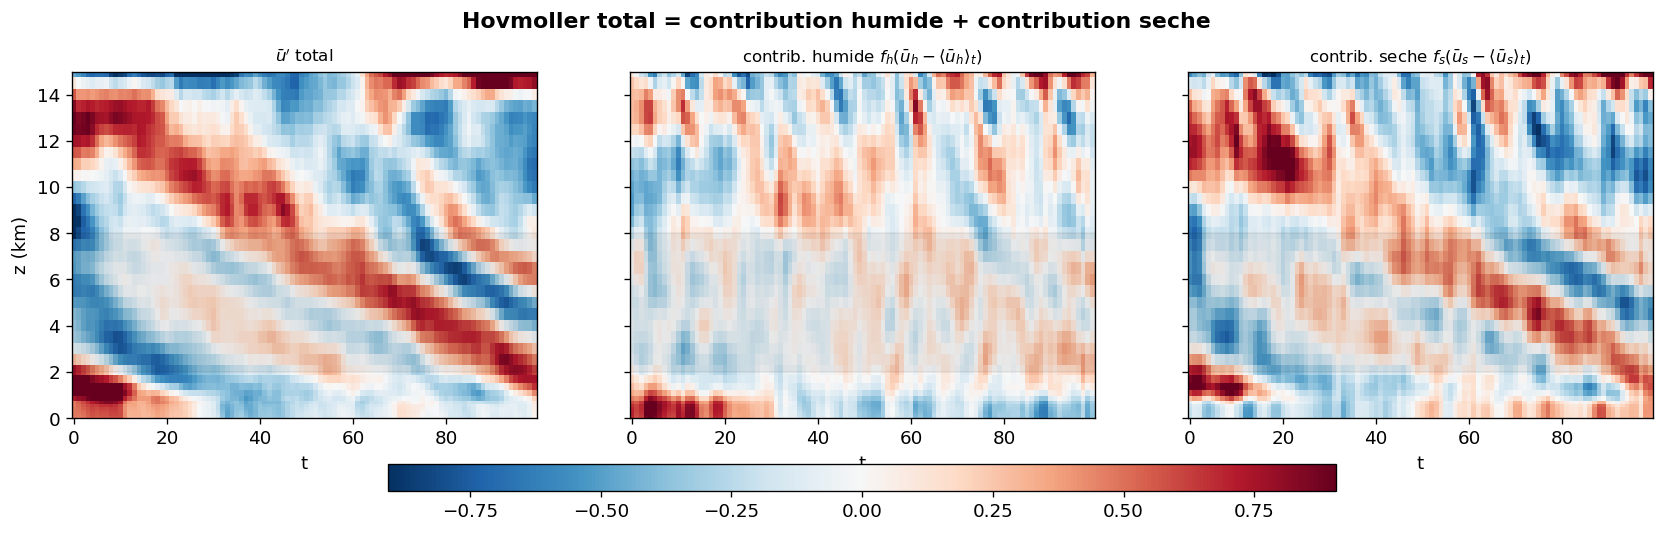

variance (2-8km) : totale=0.1801 | humide=0.0267 (15%) | seche=0.1271 (71%) | covariance=0.0263 (15%)


In [16]:
# ============================================================
#  DECOMPOSITION DU HOVMOLLER : uprime = contrib_humide + contrib_sec
# ============================================================
contrib_h = f_h*(u_h_zt - u_h_zt.mean(axis=1,keepdims=True))
contrib_s = f_s*(u_s_zt - u_s_zt.mean(axis=1,keepdims=True))
print(f'erreur max decomposition (contrib_h+contrib_s vs uprime) : '
      f'{np.max(np.abs(contrib_h+contrib_s-uprime)):.2e} m/s')

ups_h=uniform_filter1d(contrib_h,size=3,axis=0,mode='nearest')
ups_s=uniform_filter1d(contrib_s,size=3,axis=0,mode='nearest')

v=np.percentile(np.abs(ups[mask_show]),98)+1e-9
fig,axes=plt.subplots(1,3,figsize=(17,5),sharey=True)
for ax,(fld,lab) in zip(axes,[(ups,r"$\bar u'$ total"),
                               (ups_h,r"contrib. humide $f_h(\bar u_h-\langle\bar u_h\rangle_t)$"),
                               (ups_s,r"contrib. seche $f_s(\bar u_s-\langle\bar u_s\rangle_t)$")]):
    im=ax.pcolormesh(tt+t_stat, zkm[mask_show], fld[mask_show], cmap='RdBu_r',
                      norm=TwoSlopeNorm(0,-v,v), shading='auto')
    ax.axhspan(2,8,color='k',alpha=.06); ax.set_xlabel('t'); ax.set_title(lab,fontsize=10)
axes[0].set_ylabel('z (km)'); axes[0].set_ylim(0,Z_TOP_KM)
fig.colorbar(im,ax=axes,orientation='horizontal',pad=.1,aspect=35,shrink=.6)
plt.suptitle('Hovmoller total = contribution humide + contribution seche',fontweight='bold')
plt.show()

# part de variance expliquee par chaque zone (bande 2-8km)
var_tot=np.var(uprime[m28]); var_h=np.var(contrib_h[m28]); var_s=np.var(contrib_s[m28])
cov_hs=np.mean((contrib_h[m28]-contrib_h[m28].mean())*(contrib_s[m28]-contrib_s[m28].mean()))
print(f'variance (2-8km) : totale={var_tot:.4f} | humide={var_h:.4f} ({var_h/var_tot:.0%}) | '
      f'seche={var_s:.4f} ({var_s/var_tot:.0%}) | covariance={2*cov_hs:.4f} ({2*cov_hs/var_tot:.0%})')


## §6. Tendances $\partial_t$ et gradients $\partial_z$ par zone

`dtuc` = $\partial_t\bar u_{humide}$, `dtus` = $\partial_t\bar u_{sec}$, `dzuc` = $\partial_z\bar u_{humide}$, `dzus` = $\partial_z\bar u_{sec}$. 

/tmp/ipykernel_6259/919771365.py:14: MatplotlibDeprecationWarning: Auto-removal of grids by pcolor() and pcolormesh() is deprecated since 3.5 and will be removed two minor releases later; please call grid(False) first.
  im=ax.pcolormesh(tt+t_stat, zkm[mask_show], fld[mask_show], cmap='RdBu_r',


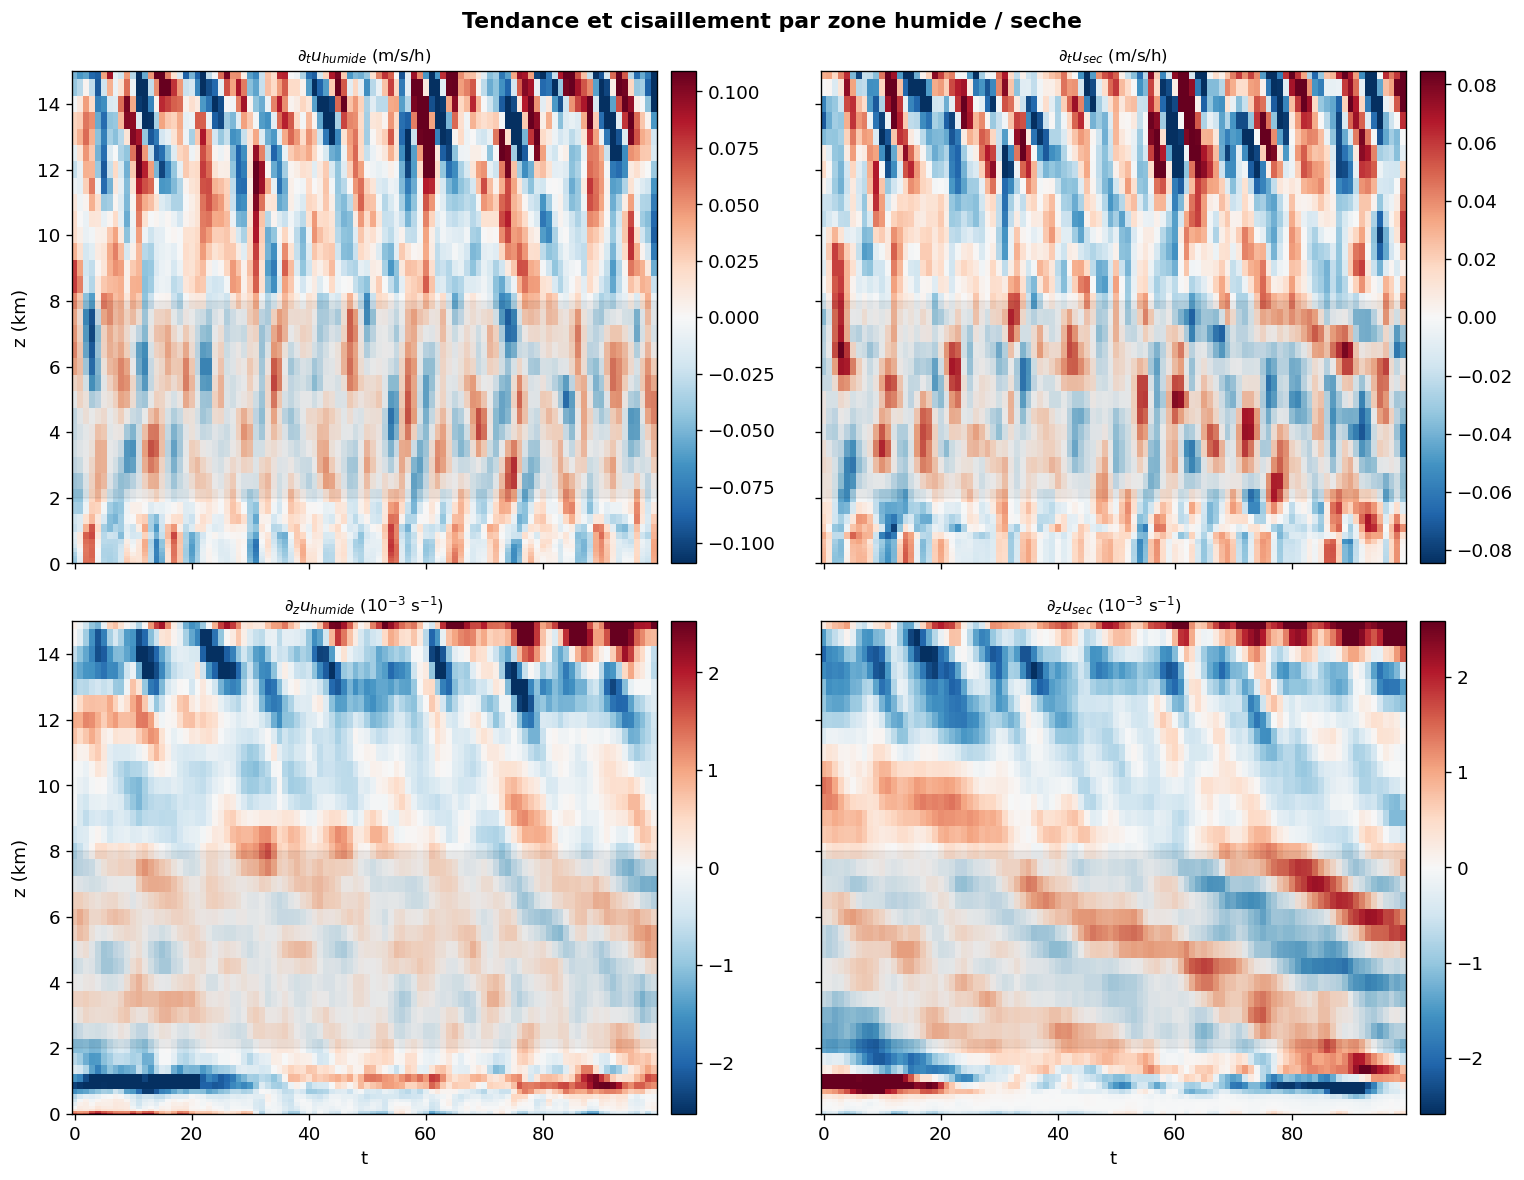

In [22]:
# ============================================================
#  dtuc / dtus (tendance temporelle) et dzuc / dzus (gradient vertical), par zone
# ============================================================
dtuc = np.gradient(u_h_zt, dt_phys, axis=1)   # tendance dans les colonnes humides
dtus = np.gradient(u_s_zt, dt_phys, axis=1)   # tendance dans les colonnes seches
dzuc = np.gradient(u_h_zt, alt, axis=0)       # cisaillement vertical, zone humide
dzus = np.gradient(u_s_zt, alt, axis=0)       # cisaillement vertical, zone seche

fig,axes=plt.subplots(2,2,figsize=(13,10),sharex=True,sharey=True)
panels=[(dtuc*3600,r"$\partial_t u_{humide}$ (m/s/h)"),(dtus*3600,r"$\partial_t u_{sec}$ (m/s/h)"),
        (dzuc*1e3,r"$\partial_z u_{humide}$ ($10^{-3}$ s$^{-1}$)"),(dzus*1e3,r"$\partial_z u_{sec}$ ($10^{-3}$ s$^{-1}$)")]
for ax,(fld,lab) in zip(axes.ravel(),panels):
    v=np.percentile(np.abs(fld[mask_show]),98)+1e-12
    im=ax.pcolormesh(tt+t_stat, zkm[mask_show], fld[mask_show], cmap='RdBu_r',
                      norm=TwoSlopeNorm(0,-v,v), shading='auto')
    ax.axhspan(2,8,color='k',alpha=.06); ax.set_title(lab,fontsize=10)
    fig.colorbar(im,ax=ax,pad=.02)
for ax in axes[:,0]: ax.set_ylabel('z (km)')
for ax in axes[1,:]: ax.set_xlabel('t')
axes[0,0].set_ylim(0,Z_TOP_KM)
plt.suptitle('Tendance et cisaillement par zone humide / seche',fontweight='bold')
plt.tight_layout(); plt.show()


## §7. Rôle de la subsidence — le nuage n'est-il qu'un mélange désordonné ?

On compare $\bar w_h(z,t)$ (zone humide, ascendance convective) et $\bar w_s(z,t)$ (zone sèche, subsidence compensatoire) à la contribution sèche du Hovmöller. Une corrélation forte et **quasi sans décalage** entre $w_{sec}'$ et la contribution sèche de $\bar u'$ appuierait l'hypothèse subsidence : la descente cohérente serait pilotée par l'advection verticale à grande échelle dans l'air clair, la zone convective n'étant qu'un mélange local sans signature propre cohérente.

/tmp/ipykernel_6259/3105534426.py:12: MatplotlibDeprecationWarning: Auto-removal of grids by pcolor() and pcolormesh() is deprecated since 3.5 and will be removed two minor releases later; please call grid(False) first.
  im=ax.pcolormesh(tt+t_stat, zkm[mask_show], fld[mask_show], cmap='RdBu_r',


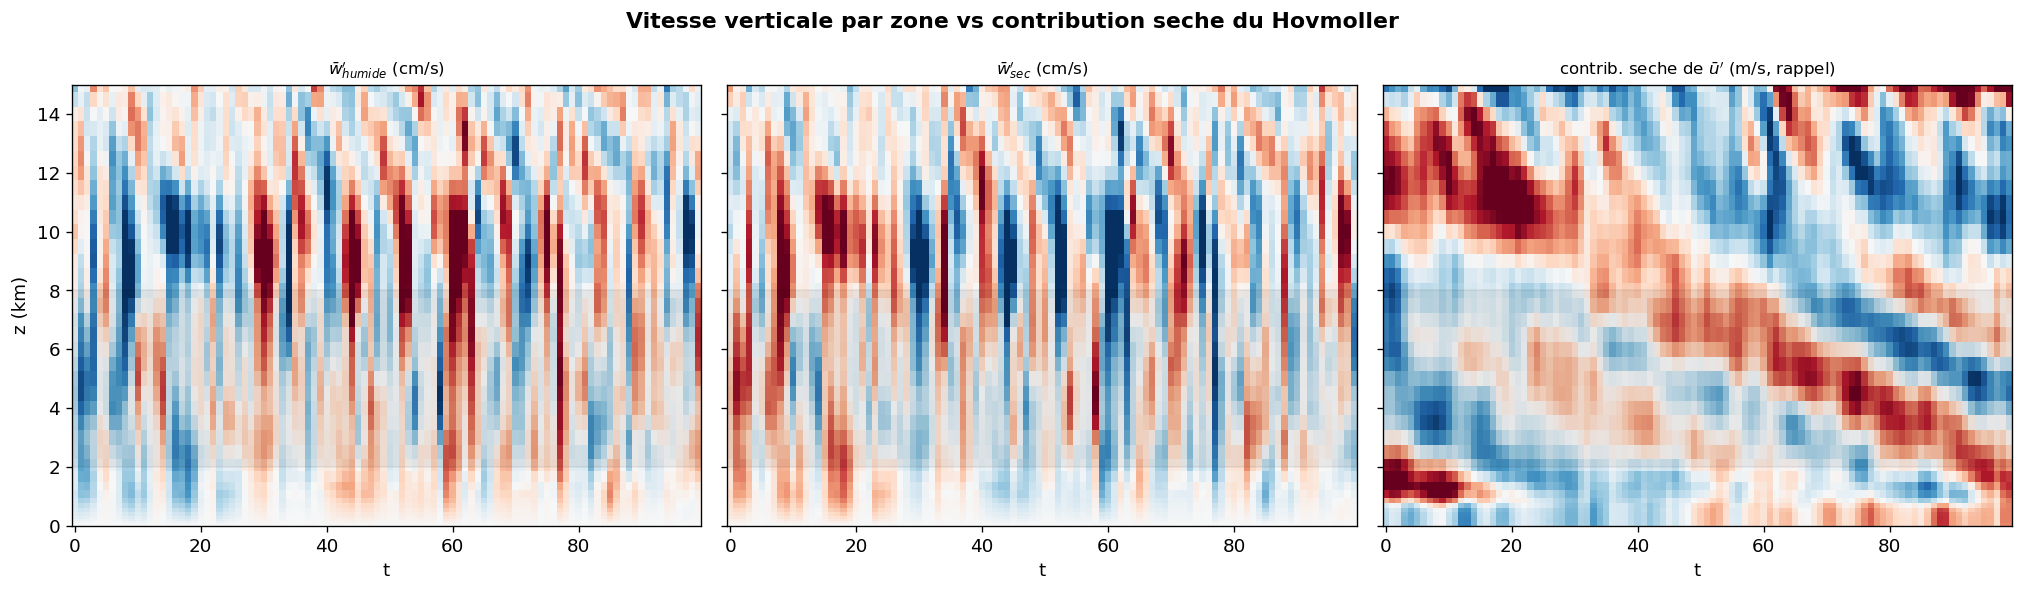

w_sec moyen (2-8km) = -0.41 cm/s  |  w_humide moyen (2-8km) = +0.54 cm/s


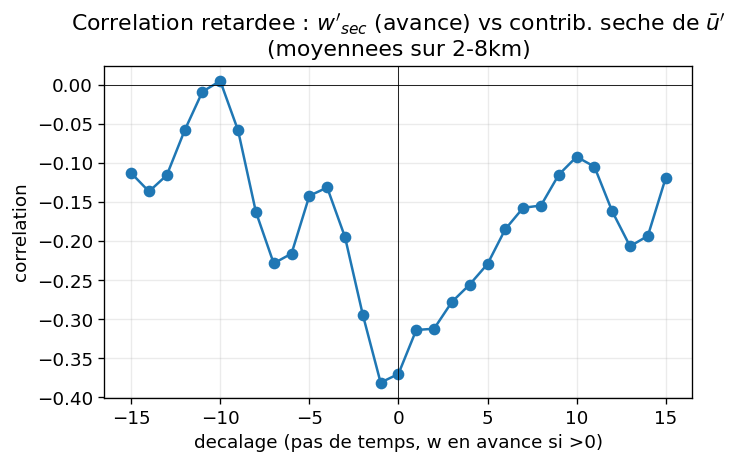

correlation max = -0.38 au decalage -1 pas de temps (-6 h)


In [18]:
# ============================================================
#  w_h(z,t) / w_s(z,t) vs contribution seche du Hovmoller
# ============================================================
wp_h = w_h_zt - w_h_zt.mean(axis=1,keepdims=True)
wp_s = w_s_zt - w_s_zt.mean(axis=1,keepdims=True)

fig,axes=plt.subplots(1,3,figsize=(17,5),sharey=True)
for ax,(fld,lab) in zip(axes,[(wp_h*100,r"$\bar w_{humide}'$ (cm/s)"),
                               (wp_s*100,r"$\bar w_{sec}'$ (cm/s)"),
                               (ups_s,r"contrib. seche de $\bar u'$ (m/s, rappel)")]):
    v=np.percentile(np.abs(fld[mask_show]),98)+1e-9
    im=ax.pcolormesh(tt+t_stat, zkm[mask_show], fld[mask_show], cmap='RdBu_r',
                      norm=TwoSlopeNorm(0,-v,v), shading='auto')
    ax.axhspan(2,8,color='k',alpha=.06); ax.set_xlabel('t'); ax.set_title(lab,fontsize=10)
axes[0].set_ylabel('z (km)'); axes[0].set_ylim(0,Z_TOP_KM)
plt.suptitle("Vitesse verticale par zone vs contribution seche du Hovmoller",fontweight='bold')
plt.tight_layout(); plt.show()

print(f"w_sec moyen (2-8km) = {w_s_zt[m28].mean()*100:+.2f} cm/s  |  "
      f"w_humide moyen (2-8km) = {w_h_zt[m28].mean()*100:+.2f} cm/s")

# correlation retardee entre w_sec' et la contribution seche de u' (bande 2-8km, moyenne sur z)
w_s_band = wp_s[m28].mean(axis=0); u_s_band = ups_s[m28].mean(axis=0)
w_s_band = (w_s_band-w_s_band.mean())/w_s_band.std()
u_s_band = (u_s_band-u_s_band.mean())/u_s_band.std()
lags=np.arange(-15,16)
xcorr=[np.corrcoef(np.roll(w_s_band,lag),u_s_band)[0,1] for lag in lags]
plt.figure(figsize=(6,4))
plt.plot(lags,xcorr,'o-'); plt.axvline(0,color='k',lw=.5); plt.axhline(0,color='k',lw=.5)
plt.xlabel('decalage (pas de temps, w en avance si >0)'); plt.ylabel('correlation')
plt.title("Correlation retardee : $w'_{sec}$ (avance) vs contrib. seche de $\\bar u'$\n(moyennees sur 2-8km)")
plt.tight_layout(); plt.show()
lag_max=lags[int(np.argmax(np.abs(xcorr)))]
print(f'correlation max = {xcorr[int(np.argmax(np.abs(xcorr)))]:+.2f} au decalage {lag_max} pas de temps '
      f'({lag_max*dt_phys/3600:+.0f} h)')
